In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [4]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [6]:
print(df.columns)
print(df.head())

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 9)


In [8]:
print(df.dtypes)

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df.select_dtypes(include='number').median()

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [11]:
df.select_dtypes(include='number').mode().iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[us]


In [13]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[us]


In [14]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

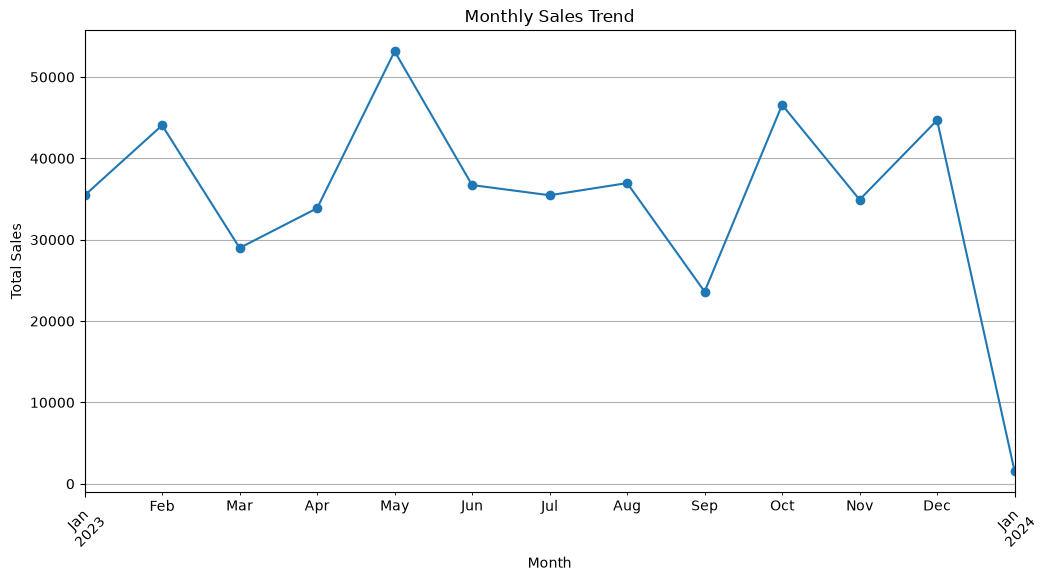

In [15]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

Monthly sales fluctuated throughout the period. Sales reached their highest point in May 2023 at 53,150, while September recorded the lowest sales in 2023 at 23,620. Sales increased significantly in October and remained relatively strong in November and December. January 2024 shows a sharp decline, which may be due to the dataset containing only a small number of transactions for that month.

In [16]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

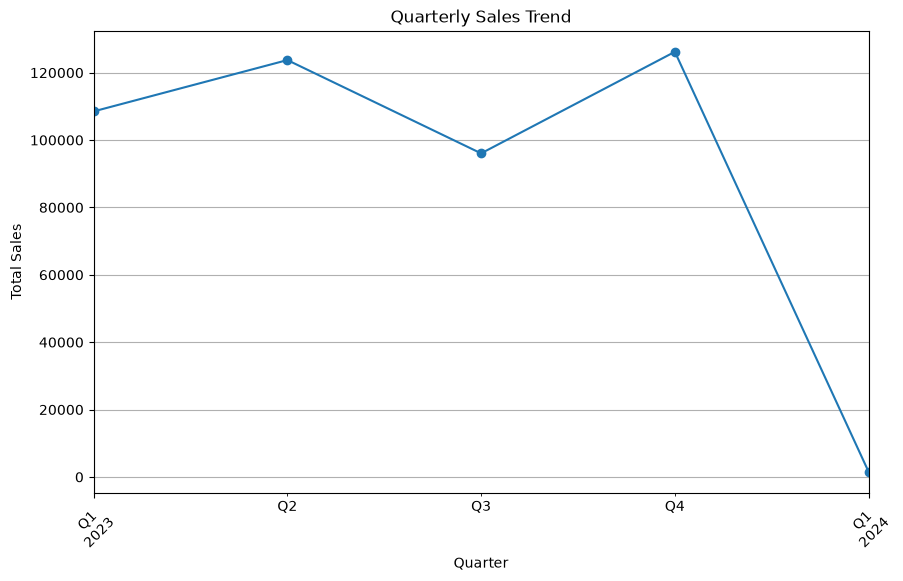

In [17]:
plt.figure(figsize=(10, 6))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

Quarterly sales increased from Q1 to Q2 2023, declined in Q3, and reached the highest level in Q4 2023 with total sales of 126,190. The strong performance in Q4 suggests that the final quarter of 2023 was the strongest sales period in the dataset. Q1 2024 shows very low sales because it contains only January 2024 data.

In [18]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-64']
)

df['Age Group'].value_counts().sort_index()

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64

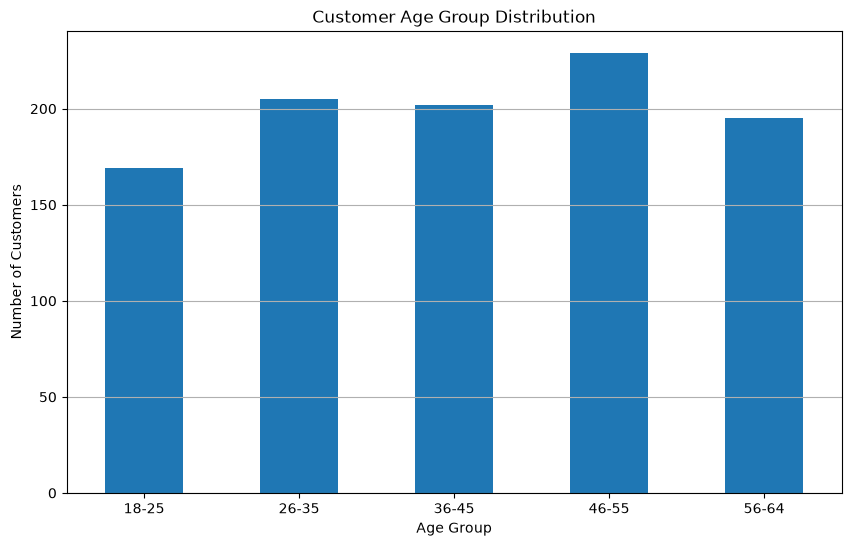

In [18]:
age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

age_counts.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

The customer base is distributed across all age groups, with customers aged 46–55 forming the largest group with 229 customers. The 18–25 age group has the fewest customers with 169. Overall, the distribution is fairly balanced, indicating that the business serves customers across a broad age range.

In [20]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

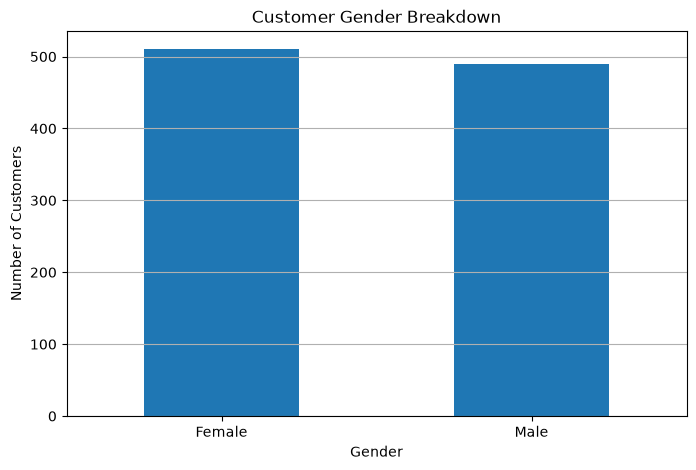

In [24]:
plt.figure(figsize=(8, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

The gender distribution is almost evenly balanced, with female customers accounting for 510 customers (51%) and male customers accounting for 490 customers (49%). This indicates that the business has a relatively balanced customer base and does not appear to be heavily dominated by either gender.

Note on Top 10 Best-Selling Products:
The dataset contains product categories but does not include individual product names or product IDs. Therefore, a true Top 10 Best-Selling Products analysis cannot be performed from the available data. Product performance was instead analysed at the product-category level.

In [25]:
category_counts = df['Product Category'].value_counts()

category_counts

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [26]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

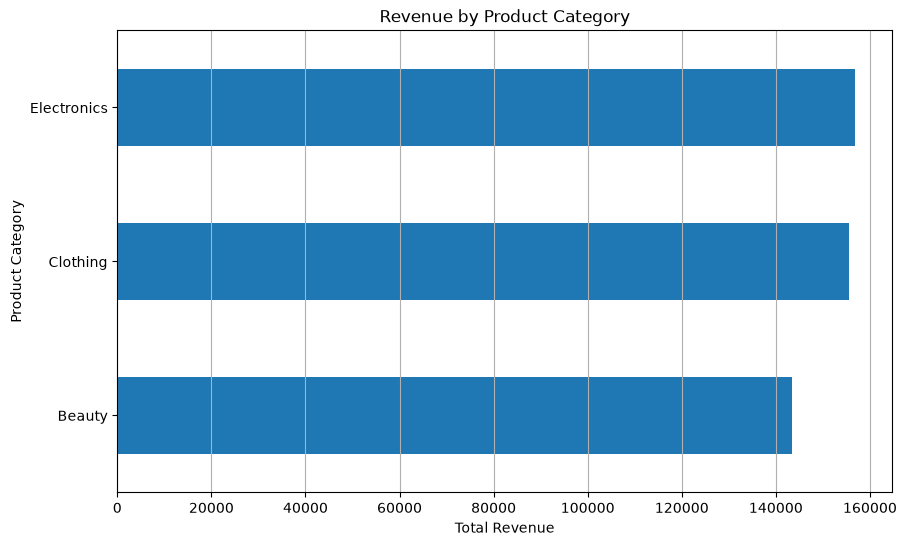

In [27]:
plt.figure(figsize=(10, 6))

category_revenue.sort_values().plot(kind='barh')

plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.grid(axis='x')

plt.show()

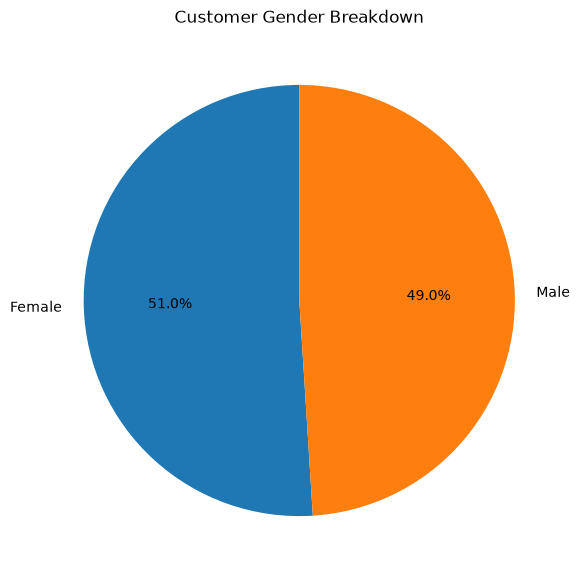

In [28]:
plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Gender Breakdown')
plt.show()

In [29]:
correlation_matrix = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


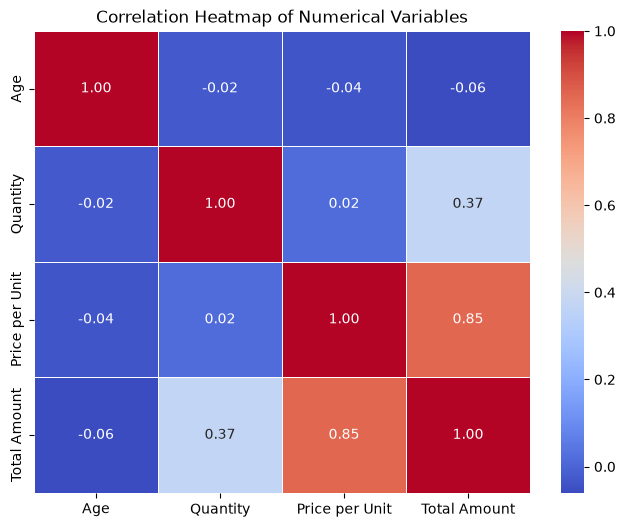

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

The heatmap shows a strong positive correlation of 0.85 between Price per Unit and Total Amount. Quantity has a moderate positive correlation of 0.37 with Total Amount. Age has very weak correlations with the other numerical variables, suggesting that age does not have a strong linear relationship with purchasing behaviour in this dataset.

In [33]:
age_group_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum().sort_values(ascending=False)
age_group_sales

Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-64     80410
Name: Total Amount, dtype: int64

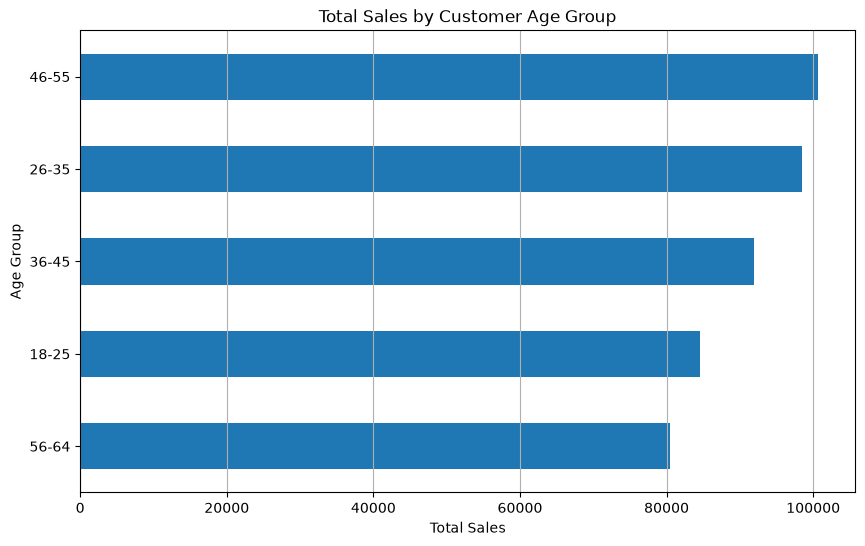

In [34]:
plt.figure(figsize=(10, 6))

age_group_sales.sort_values().plot(kind='barh')

plt.title('Total Sales by Customer Age Group')
plt.xlabel('Total Sales')
plt.ylabel('Age Group')
plt.grid(axis='x')

plt.show()

Customers aged 46–55 generated the highest total sales of 100,690, while customers aged 56–64 generated the lowest at 80,410. This indicates that the largest-spending customer group is also the 46–55 age group, while the oldest age group contributes comparatively less revenue. The result suggests that customers in the 46–55 age range may represent an important target segment for marketing and promotional activities.

Conclusion

The exploratory data analysis provided useful insights into the sales performance and customer characteristics of the retail business. Sales fluctuated throughout the period, with May 2023 recording the highest monthly sales of 53,150 and Q4 2023 recording the highest quarterly sales of 126,190. The customer base was relatively balanced across genders, while customers aged 46–55 generated the highest total sales of 100,690.

At the product-category level, Electronics generated the highest revenue of 156,905, followed closely by Clothing and Beauty. The correlation analysis also showed a strong positive relationship between Price per Unit and Total Amount (0.85), while Quantity had a moderate positive relationship with Total Amount (0.37).

Based on these findings, the following recommendations are proposed:

1. Target the 46–55 age group: Develop targeted promotions and marketing campaigns for this customer segment because it generated the highest total sales.
2. Strengthen Electronics marketing: Increase promotional efforts and product visibility for Electronics because it generated the highest category revenue.
3. Address low-sales periods: Investigate the causes of weaker sales periods, particularly September 2023, and introduce targeted promotions or campaigns to improve performance during such periods.